#### environment

In [ ]:
import os 
import numpy as np
from numpy import full
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from scipy.stats import linregress

In [7]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

In [8]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
                    1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

In [17]:
def five_turning_curves(arrays: list or np.array, titles: list, ten_neurons: list = [i for i in range(10)]):
    """
    Parameters
    ----------
    arrays: list
        list of output arrys to plot (sum arrays from predict loop)
    titles: list
        list of corresponding titles for each plot
    ten_neurons: list
        list of ten neurons to use, defaults to first ten 
    """
    fig, axes = plt.subplots(5, 1, figsize=(4, 20), sharex=True)

    image_ids = np.array([i for i in range(5)], dtype=int)

    for ax, array, title in zip(axes, arrays, titles):
        mean_array = np.mean(array, axis=1) 
        variance = np.var(array, axis=1)
        std_dev = np.sqrt(variance)

        for neuron in ten_neurons:
            neuron_predictions = mean_array[:, neuron]
            ax.errorbar(image_ids, neuron_predictions, yerr=std_dev[:, neuron],
                        marker='o', linestyle='-', capsize=5)

        ax.set_title(f"{title}", fontsize=10)
        ax.set_ylabel("Mean Predicted Spike Count")
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.grid(True)
    plt.xlabel('Image ID')
    plt.tight_layout()
    plt.show()

In [19]:
d3_sum_r1.shape

(5, 100, 5312)

In [20]:
no_noise_sum_r1.shape

(5, 100, 5312)

#### random neurons by region

In [22]:
r1_randoms = np.random.randint(0, d3_sum_r1.shape[2], 10)
r1_randoms

array([2186, 2831,  211,  895, 3346, 3478, 2152,  222, 5002, 2599])

In [23]:
r1_randoms = [2186, 2831,  211,  895, 3346, 3478, 2152,  222, 5002, 2599]

In [24]:
r2_randoms = np.random.randint(0, d3_sum_r2.shape[2], 10)
r2_randoms

array([786,  47, 231, 183, 446, 410, 181, 434, 872, 744])

In [25]:
r2_randoms = [786,  47, 231, 183, 446, 410, 181, 434, 872, 744]

In [26]:
r3_randoms = np.random.randint(0, d3_sum_r3.shape[2], 10)
r3_randoms

array([218, 242, 168, 202,   9, 134, 277, 371,  65,  24])

In [27]:
r3_randoms = [218, 242, 168, 202,   9, 134, 277, 371,  65,  24]

In [28]:
r4_randoms = np.random.randint(0, d3_sum_r4.shape[2], 10)
r4_randoms

array([213, 176, 795, 577, 561, 265, 497, 179, 338, 260])

In [29]:
r4_randoms = [213, 176, 795, 577, 561, 265, 497, 179, 338, 260]

#### load predictions

In [11]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_noise + '.npy'
        var_name = noise + type_noise
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        globals()[var_name] = np.load(path)

In [12]:
# load predictions by region
for region in np.unique(d3_labels):
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = noise + type_noise + '_r' + str(region) +  '.npy'
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            array_name = noise + type_noise + '_r' + str(region)
            globals()[array_name] = np.load(path)

#### plots

In [33]:
sums_dr1 = [no_noise_sum_r1, d3_sum_r1, d15_sum_r1, d30_sum_r1, dbin_sum_r1]
titles_dr1 = ['Region 1, Dynamic\nNo Noise', 'Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic\nBinarization']

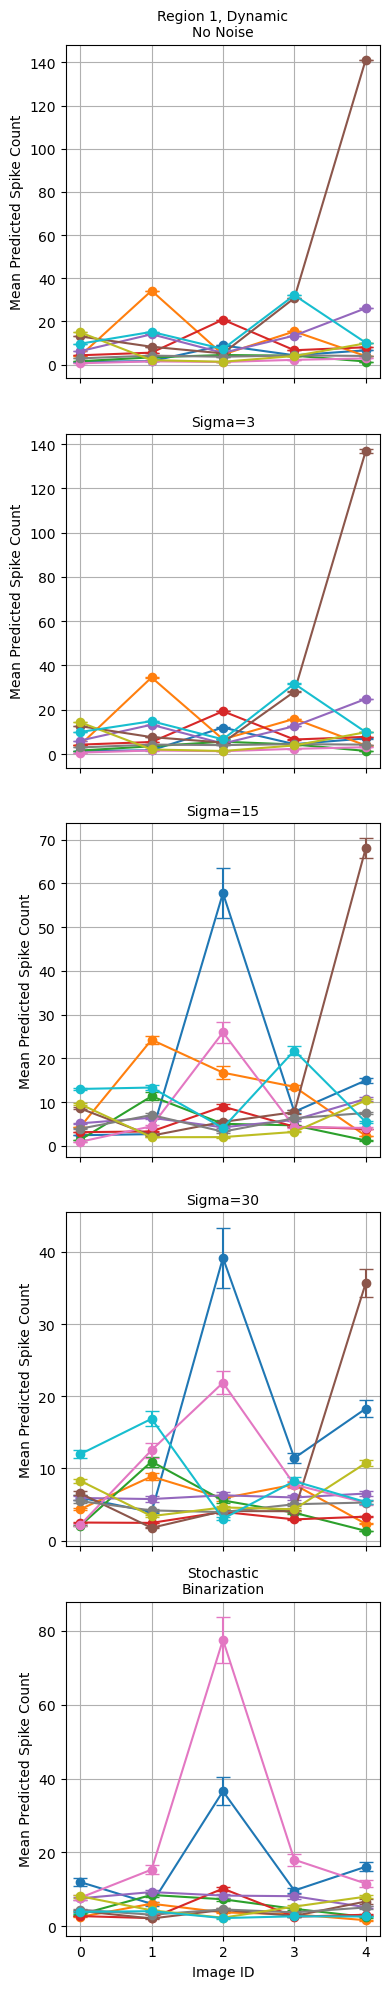

In [34]:
five_turning_curves(sums_dr1, titles_dr1, r1_randoms)

In [35]:
sums_cr1 = [no_noise_sum_r1, c3_sum_r1, c15_sum_r1, c30_sum_r1, cbin_sum_r1]
titles_cr1 = ['Region 1, Constant\nNo Noise', 'Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic\nBinarization']

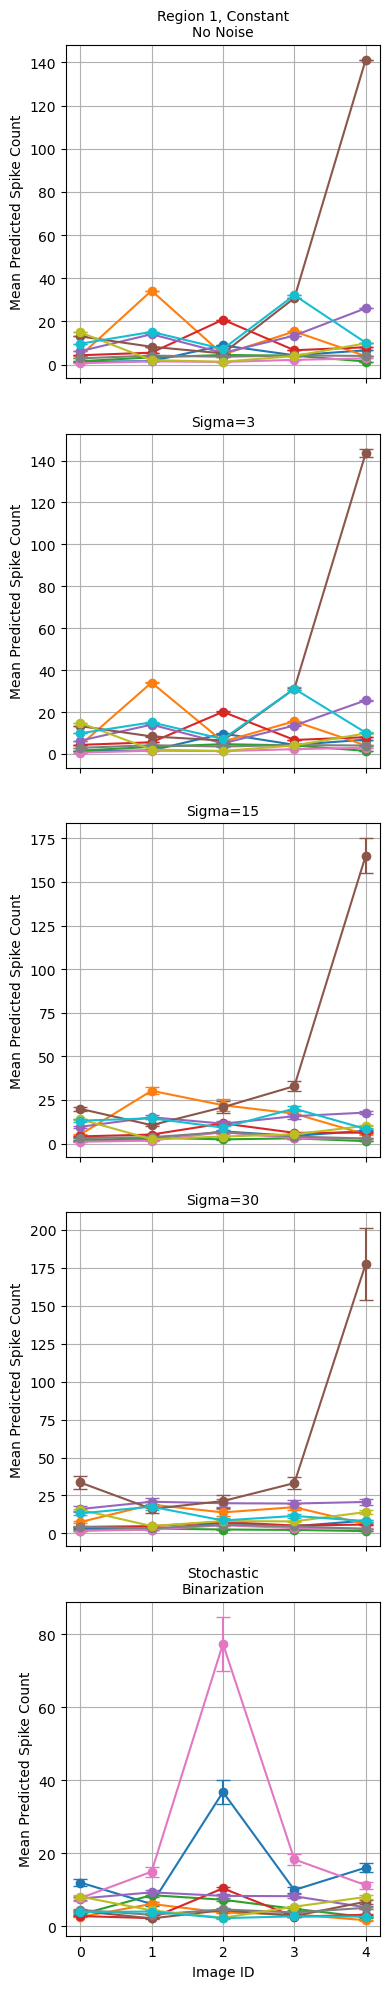

In [36]:
five_turning_curves(sums_cr1, titles_cr1, r1_randoms)

In [40]:
sums_dr2 = [no_noise_sum_r2, d3_sum_r2, d15_sum_r2, d30_sum_r2, dbin_sum_r2]
titles_dr2 = ['Region 2, Dynamic\nNo Noise', 'Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic\nBinarization']

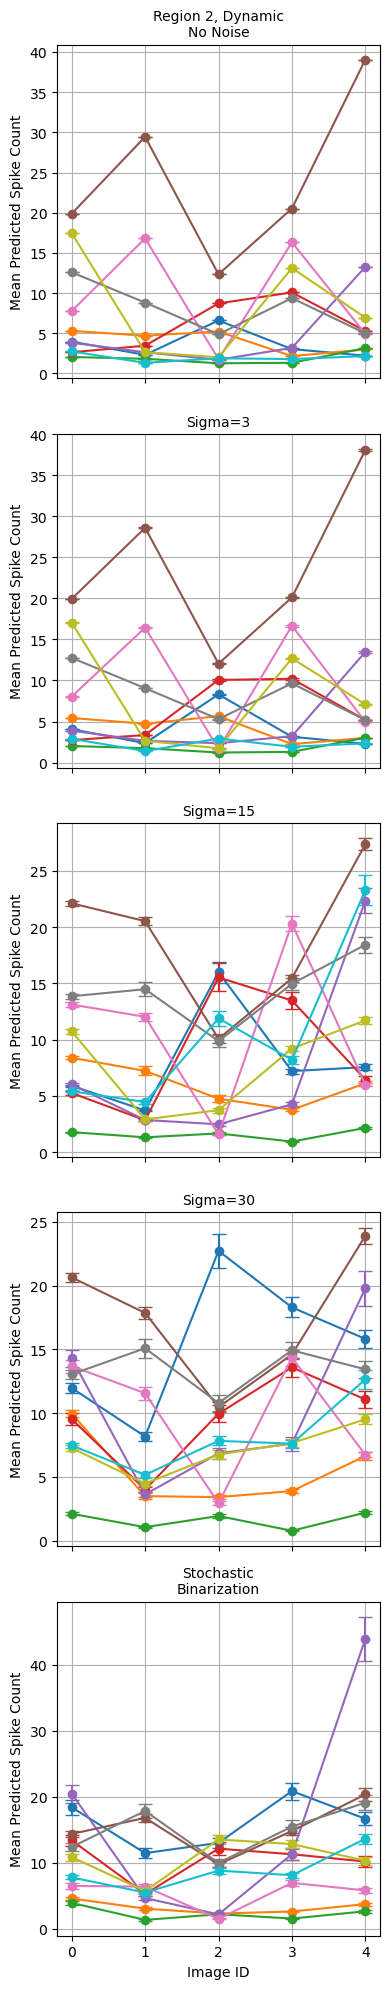

In [41]:
five_turning_curves(sums_dr2, titles_dr2, r2_randoms)

In [42]:
sums_cr2 = [no_noise_sum_r2, c3_sum_r2, c15_sum_r2, c30_sum_r2, cbin_sum_r2]
titles_cr2 = ['Region 2, Constant\nNo Noise', 'Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic\nBinarization']

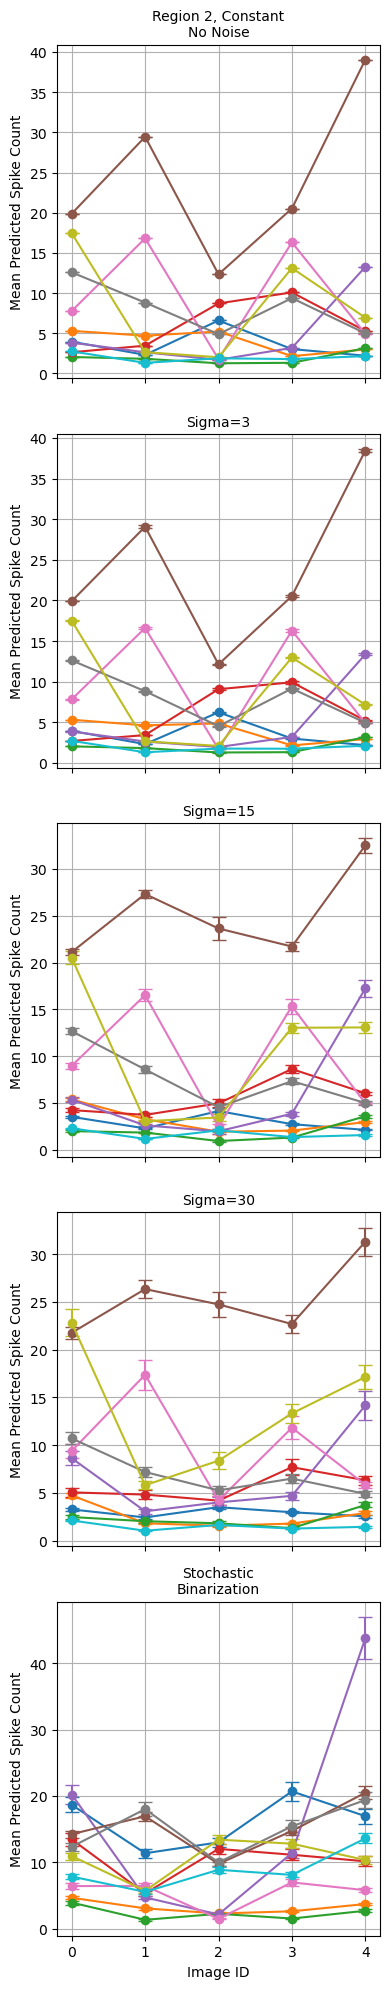

In [44]:
five_turning_curves(sums_cr2, titles_cr2, r2_randoms)

In [45]:
sums_dr3 = [no_noise_sum_r3, d3_sum_r3, d15_sum_r3, d30_sum_r3, dbin_sum_r3]
titles_dr3 = ['Region 3, Dynamic\nNo Noise', 'Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic\nBinarization']

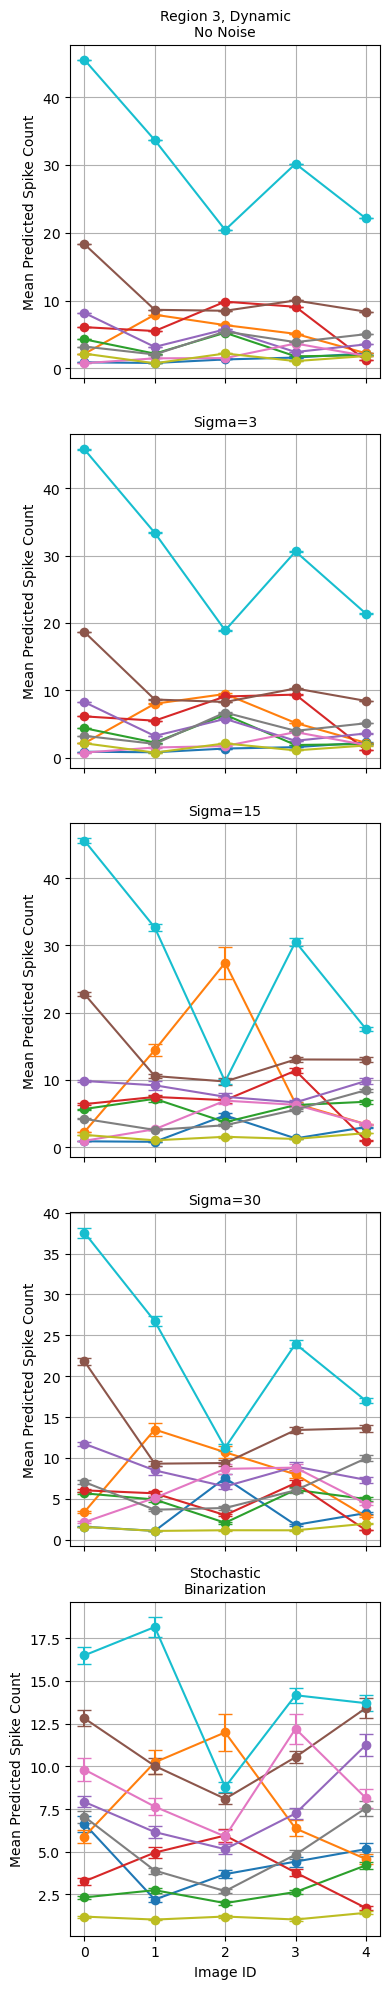

In [46]:
five_turning_curves(sums_dr3, titles_dr3, r3_randoms)

In [47]:
sums_cr3 = [no_noise_sum_r3, c3_sum_r3, c15_sum_r3, c30_sum_r3, cbin_sum_r3]
titles_cr3 = ['Region 3, Constant\nNo Noise', 'Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic\nBinarization']

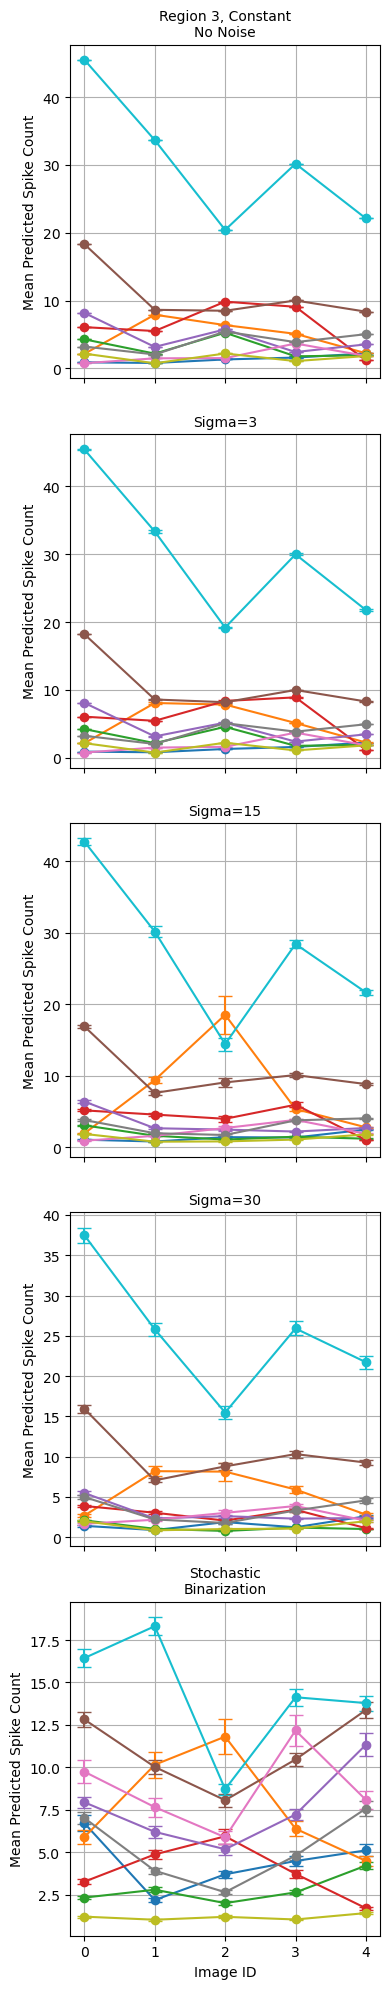

In [48]:
five_turning_curves(sums_cr3, titles_cr3, r3_randoms)

In [49]:
sums_dr4 = [no_noise_sum_r4, d3_sum_r4, d15_sum_r4, d30_sum_r4, dbin_sum_r4]
titles_dr4 = ['Region 4, Dynamic\nNo Noise', 'Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic\nBinarization']

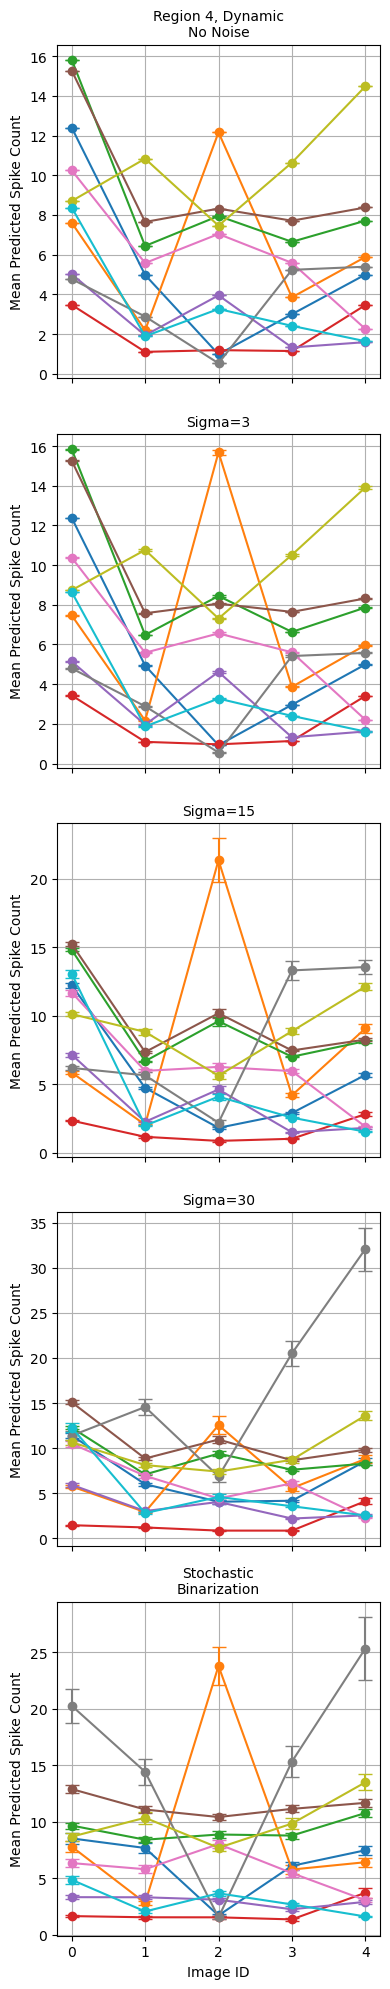

In [50]:
five_turning_curves(sums_dr4, titles_dr4, r4_randoms)

In [51]:
sums_cr4 = [no_noise_sum_r4, c3_sum_r4, c15_sum_r4, c30_sum_r4, cbin_sum_r4]
titles_cr4 = ['Region 4, Constant\nNo Noise', 'Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic\nBinarization']

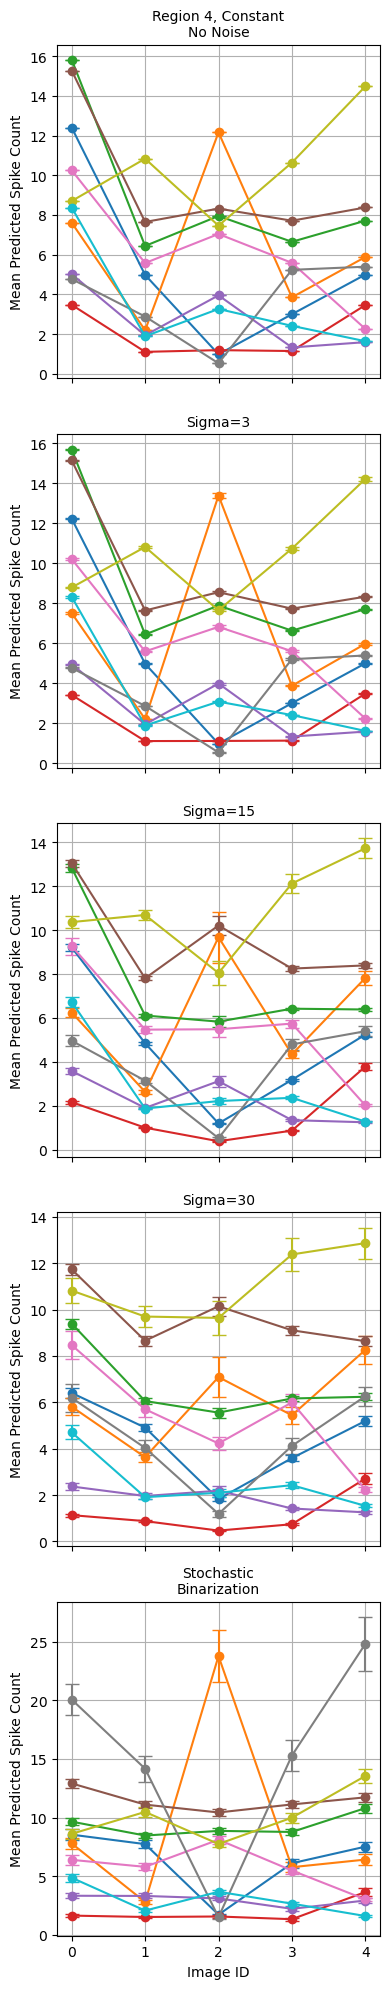

In [53]:
five_turning_curves(sums_cr4, titles_cr4, r4_randoms)